## Performance Prediction & Composition via Stochastic Network Calculus (SNC)

This notebook implements the probabilistic end-to-end performance modeling methodology (PEGASUS) on a small synthetic
system, so that every step can be inspected and the ground truth is known:

1. **Learning (Sections 1–5):** one Gaussian Process (GP) per service predicts the execution time of an item from the
   configuration.
2. **Node bounds (Section 6):** from the GP's Gaussian Moment Generating Function (MGF), a bound on the latency (sojourn
   time) of one service at arrival rate $\lambda$ that is violated with probability at most $\varepsilon$. Three node
   bounds are compared: the SNC queueing bound (6), the SNC bound with propagated arrival models (6a), and the
   martingale bound (6b).
3. **Composition (Sections 7–9):** node bounds are added along the pipeline with the violation budget split over the
   nodes (union bound). This is the Probabilistic Performance Guarantee (PPG); it holds for any dependence between
   services.

The ground truth is a simulated queueing pipeline (one FIFO server per service, item sizes shared across services),
fed by Poisson or periodic arrivals (`arrival_process` in the first cell). The bounds are checked against simulated
end-to-end latencies, not against execution times alone. The violation probability $\varepsilon$ is `alpha` in the
code. The helpers shared with `why_poisson_is_loose.ipynb` (arrival models, bounds, simulator) are in `snc_bounds.py`;
the changes to this notebook are listed in the changelog at the end.

In [1]:
# ==============================================================================
# Performance Prediction & Composition via SNC
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, Matern, WhiteKernel
from sklearn.preprocessing import StandardScaler

from snc_bounds import (latency_bound_from_moment, log_latency_moment, martingale_node_bound, propagated_node_bounds,
                        simulate_chain, snc_latency_bound)

# Set global seed for reproducibility
np.random.seed(35)

# Violation probability epsilon of every bound (alpha = 0.0001 -> 99.99% SLA guarantee)
alpha = 0.05
z_score = norm.ppf(1 - alpha)

# Format dynamic percentile label (e.g., '99.99' or '95')
p_pct = (1 - alpha) * 100
p_str = f"{p_pct:.2f}".rstrip('0').rstrip('.')

# Workload and ground truth
arrival_rate = 3.0        # lambda: items per second offered to the pipeline
# arrival process of the items entering the pipeline
#   "poisson" : exponential gaps with mean 1/lambda (many unsynchronized devices)
#   "periodic": gaps of (1/lambda) * (1 + U(-arrival_jitter, arrival_jitter)) (one device or stream at a fixed rate)
arrival_process = "poisson"
arrival_jitter = 0.1      # relative half-width of the uniform jitter on periodic gaps, in [0, 1)
item_correlation = 0.7    # correlation of an item's execution-time noise across services (a large item is slow everywhere)
n_sim_items = 5000        # items per simulated run of the ground truth
workload = dict(process=arrival_process, rate=arrival_rate, jitter=arrival_jitter)   # passed to every bound and simulation

# Confidence level at which epistemic uncertainty enters the bounds (Section 6)
confidence = 0.95
z_confidence = norm.ppf(confidence)

# Formatting of conclusions that are rendered from the results
pct = lambda value: f"{value:.0%}"
ratio = lambda value: f"{value:.2f}×"


def span(values, fmt):
    # "between a and b", or just "a" if both round to the same text
    low, high = fmt(np.min(values)), fmt(np.max(values))
    return low if low == high else f"between {low} and {high}"

## 1. Synthetic Data Generation
We simulate execution time demands for a pipeline of three microservices ($s_1 \to s_2 \to s_3$).

The configuration $x$ = (CPU, quality, parallelism) of a service determines the execution time of an item. The arrival
rate $\lambda$ (items/s) and the arrival process (`arrival_process`: Poisson or periodic) determine how many items
queue, above all at the first service. The training data below are single-service measurements of execution time; the
ground truth for latencies also includes queueing (Section 1b).

In [2]:
def true_demand(x, service_type):
    """Simulates latency demand d(x) = f(cpu, quality, parallelism)."""
    cpu, quality, parallelism = x[:, 0], x[:, 1], x[:, 2]
    if service_type == "type_A":
        return 0.010 + 0.040 / cpu + 0.030 * (quality ** 2.0)
    elif service_type == "type_B":
        return 0.012 + 0.035 / cpu + 0.025 * (quality ** 1.5)
    else:
        return 0.008 + 0.030 / cpu + 0.020 * (quality ** 1.8)

n_train = 50
X_train = np.column_stack([
    np.random.uniform(0.5, 2.0, n_train),  # CPU
    np.random.uniform(0.5, 2.0, n_train),  # Quality
    np.random.uniform(1.0, 4.0, n_train)  # Parallelism
])

service_names = ["s1", "s2", "s3"]
service_types = ["type_A", "type_B", "type_C"]
y_train_dict = {}

# Standard deviation of the execution-time noise per service (s)
noise_levels = {
    "s1": 0.0060,  # high variance
    "s2": 0.0010,  # low variance (stable)
    "s3": 0.0035   # medium variance
}

for s_name, s_type in zip(service_names, service_types):
    y_clean = true_demand(X_train, s_type)
    noise = np.random.normal(0, noise_levels[s_name], n_train)
    y_train_dict[s_name] = y_clean + noise

print("Training dataset successfully generated.")

Training dataset successfully generated.


## 1b. Ground Truth: the Pipeline as a Queueing System

Items arrive at rate $\lambda$, either as a Poisson process or periodically with uniform jitter (`arrival_process`).
Every service is one FIFO server; an item leaves $s_k$ and immediately enters $s_{k+1}$ (workload propagation). The
execution time of item $i$ at service $k$ is $d_k(x) + \sigma_k z_{ik}$, where the noise $z_{ik}$ is shared across
services with correlation `item_correlation`: a large request is slow at every service. The marginal execution time of
each service is exactly the one the training data was drawn from, so the GPs are not affected.

The latency (sojourn time) of an item at a service is its queueing wait plus its execution time. The ground-truth
$(1-\varepsilon)$ latency quantile of a configuration is estimated from `n_sim_items` simulated items.

A simpler ground truth, the sum of independent Gaussian execution times without any queue, is kept as a baseline in
Section 7: it does not depend on $\lambda$, and its nodes are independent by construction.

In [3]:
# Ground truth: the chain simulator of snc_bounds with the mean execution times of true_demand.
# Vectorized over configurations: x_cfgs has one row per configuration.
def simulate_pipeline(x_cfgs, path_types, path_noise_levels, n_items, item_correlation, rng, workload):
    """Per-node latencies (configurations, items, nodes) and end-to-end latencies (configurations, items)."""
    x_cfgs = np.atleast_2d(x_cfgs)
    mean_execution = np.column_stack([true_demand(x_cfgs, s_type) for s_type in path_types])
    return simulate_chain(mean_execution, path_noise_levels, n_items=n_items, item_correlation=item_correlation, rng=rng, **workload)


def quantile_per_config(samples, level=1 - alpha):
    return np.quantile(samples, level, axis=1)


print("Ground-truth simulator ready.")

Ground-truth simulator ready.


## 2. Learning Stage (Gaussian Process Surrogate Models)

We train a GP for each service to capture execution time distributions, decomposing epistemic (model) and aleatoric (noise) uncertainties.

In [4]:
class ScaledGPRegressor:
    """
    Wrapper around GaussianProcessRegressor that handles feature (X) scaling
    and leverages native `normalize_y=True` for target scaling.

    Explicitly decomposes total predictive variance V[Y(x)] into:
    - Epistemic uncertainty: Var(f(x))
    - Aleatoric uncertainty: sigma_n^2 (from WhiteKernel, unscaled to physical units)
    """
    def __init__(self, kernel, n_restarts_optimizer=5, random_state=42):
        self.x_scaler = StandardScaler()
        self.gp = GaussianProcessRegressor(
            kernel=kernel,
            normalize_y=True,  # Handles y-scaling natively & unscales predict() outputs
            n_restarts_optimizer=n_restarts_optimizer,
            random_state=random_state
        )

    def fit(self, X, y):
        X_scaled = self.x_scaler.fit_transform(X)
        self.gp.fit(X_scaled, y)
        return self

    def predict(self, X, return_std=False, return_variance_components=False):
        X_scaled = self.x_scaler.transform(X)

        # Epistemic standard deviation sqrt(Var(f(x))) - natively unscaled by sklearn
        mu, std_epistemic = self.gp.predict(X_scaled, return_std=True)
        var_epistemic = std_epistemic ** 2

        # Extract target scaling factor (sigma_y) used internally when normalize_y=True
        y_std = getattr(self.gp, '_y_train_std', 1.0)
        y_var_scale = y_std ** 2

        # Extract aleatoric noise level sigma_n^2 and convert from scaled space to physical units
        if hasattr(self.gp.kernel_, 'k2') and hasattr(self.gp.kernel_.k2, 'noise_level'):
            var_aleatoric_scaled = self.gp.kernel_.k2.noise_level
            var_aleatoric = np.full_like(var_epistemic, var_aleatoric_scaled * y_var_scale)
        else:
            var_aleatoric = np.zeros_like(var_epistemic)

        # Total variance V[Y(x)] = Var(f(x)) + sigma_n^2 (all in physical units)
        var_total = var_epistemic + var_aleatoric
        std_total = np.sqrt(var_total)

        if return_variance_components:
            return mu, std_total, var_epistemic, var_aleatoric
        if return_std:
            return mu, std_total

        return mu


def train_gp_models(X_train: np.ndarray, y_train_dict: dict, service_names: list) -> dict:
    """Fits ScaledGPRegressor models for each service."""
    models = {}
    for name in service_names:
        kernel = (
            C(1.0, (1e-2, 1e2)) * Matern(length_scale=1.0, nu=2.5) +
            WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 1e-1))
        )

        model = ScaledGPRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42)
        model.fit(X_train, y_train_dict[name])
        models[name] = model

    return models

gp_models = train_gp_models(X_train, y_train_dict, service_names)
print("Trained GP models for all microservices.")

Trained GP models for all microservices.


## 3. Visualization: Fitted GPs along a Feature Slice

Here we visualize the GP predictive distributions along a slice varying CPU while fixing Quality and Parallelism.

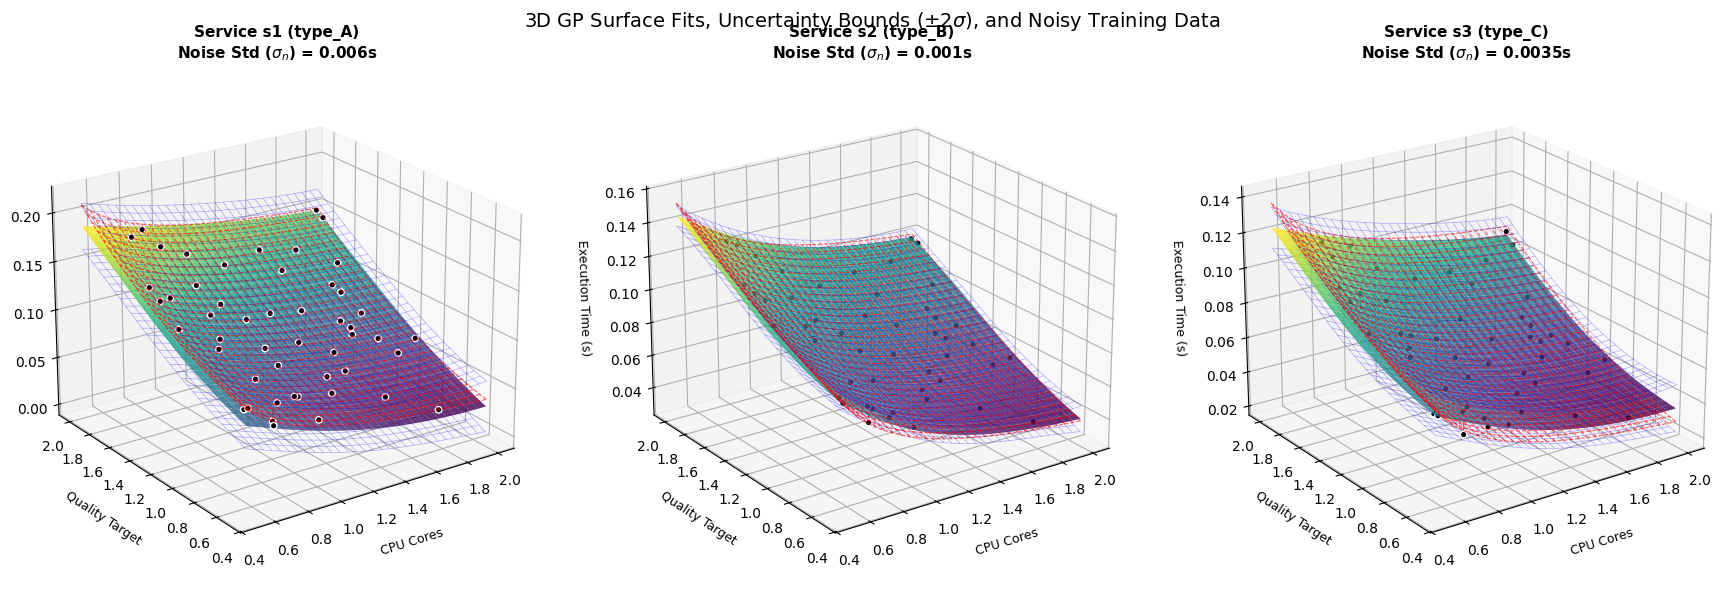

In [5]:
from mpl_toolkits.mplot3d import Axes3D

# Create 2D grid across both CPU (cores) and Quality
n_grid = 30
cpu_axis = np.linspace(0.5, 2.0, n_grid)
quality_axis = np.linspace(0.5, 2.0, n_grid)

CPU_grid, QUALITY_grid = np.meshgrid(cpu_axis, quality_axis)
PARALLELISM_grid = np.full_like(CPU_grid, 2.0)  # fixed parallelism

# Flatten grid for predictions
X_grid_3d = np.column_stack([
    CPU_grid.ravel(),
    QUALITY_grid.ravel(),
    PARALLELISM_grid.ravel()
])

fig = plt.figure(figsize=(18, 6), dpi=100)

for idx, (s_name, s_type) in enumerate(zip(service_names, service_types), 1):
    ax = fig.add_subplot(1, 3, idx, projection='3d')

    # Predict GP mean and standard deviation across 2D grid
    mu, std = gp_models[s_name].predict(X_grid_3d, return_std=True)
    mu_surface = mu.reshape(n_grid, n_grid)
    std_surface = std.reshape(n_grid, n_grid)

    # 1. Plot GP Predicted Mean Surface (Solid Mesh)
    surf_mean = ax.plot_surface(
        CPU_grid, QUALITY_grid, mu_surface,
        cmap='viridis', alpha=0.8, edgecolor='none', label=r"GP Mean $\mu(x)$"
    )

    # 2. Plot GP Uncertainty Envelope (+- 2 std) as transparent wireframes
    ax.plot_wireframe(
        CPU_grid, QUALITY_grid, mu_surface + 2 * std_surface,
        color='blue', linewidth=0.5, alpha=0.3, label=r"Upper Bound ($\mu + 2\sigma$)"
    )
    ax.plot_wireframe(
        CPU_grid, QUALITY_grid, mu_surface - 2 * std_surface,
        color='blue', linewidth=0.5, alpha=0.3, label=r"Lower Bound ($\mu - 2\sigma$)"
    )

    # 3. Plot True Demand (Red Dashed Wireframe)
    y_true_surface = true_demand(X_grid_3d, s_type).reshape(n_grid, n_grid)
    ax.plot_wireframe(
        CPU_grid, QUALITY_grid, y_true_surface,
        color='red', linewidth=0.8, linestyle='--', alpha=0.6, label=r"True Demand $f(x)$"
    )

    # 4. Scatter Training Samples with Vertical Drop Lines to see 3D position clearly
    x_train_cpu = X_train[:, 0]
    x_train_qual = X_train[:, 1]
    y_train_obs = y_train_dict[s_name]

    # Draw vertical stem lines connecting each point to the GP Mean
    for x_c, x_q, y_o in zip(x_train_cpu, x_train_qual, y_train_obs):
        # Predict mean at specific point to draw residual stem
        mu_pt = gp_models[s_name].predict(np.array([[x_c, x_q, 2.0]]))
        ax.plot([x_c, x_c], [x_q, x_q], [mu_pt[0], y_o], color='black', alpha=0.4, linewidth=0.8)

    # Scatter actual noisy observations
    ax.scatter(
        x_train_cpu, x_train_qual, y_train_obs,
        color='black', s=22, edgecolors='white', alpha=1.0, zorder=10, label="Observed Training Data"
    )

    # Aesthetics & Labels
    ax.set_title(f"Service {s_name} ({s_type})\nNoise Std ($\\sigma_n$) = {noise_levels[s_name]}s", fontsize=11, fontweight='bold')
    ax.set_xlabel("CPU Cores", fontsize=9, labelpad=8)
    ax.set_ylabel("Quality Target", fontsize=9, labelpad=8)
    ax.set_zlabel("Execution Time (s)", fontsize=9, labelpad=8)
    ax.view_init(elev=22, azim=-125)

plt.suptitle(r"3D GP Surface Fits, Uncertainty Bounds ($\pm 2\sigma$), and Noisy Training Data", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

## 4. Visualization: Coverage Analysis of the GP (Test Dataset)

We evaluate empirical coverage on a held-out test dataset to verify that the GP's predictive distribution holds at
the targeted violation probability $\varepsilon$ (`alpha` in the first cell).

This section checks step 1 only: whether a single new *execution time* falls below the GP's predictive quantile
$\mu + z\sigma$. It is not a check of the latency bound, which also includes queueing; that check is in Section 6c.
The test inputs are drawn from the training range.

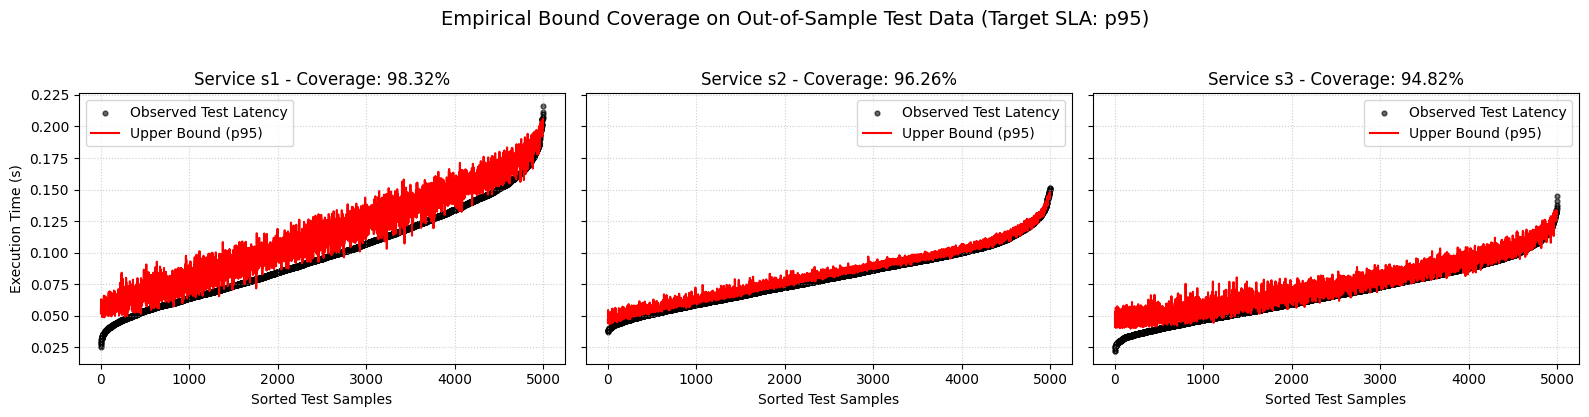

In [6]:
n_test = 5000
X_test = np.column_stack([
    np.random.uniform(0.5, 2.0, n_test),
    np.random.uniform(0.5, 2.0, n_test),
    np.random.uniform(1.0, 4.0, n_test)
])

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, s_name, s_type in zip(axes, service_names, service_types):
    y_true_test = true_demand(X_test, s_type) + np.random.normal(0, noise_levels[s_name], n_test)
    mu_test, std_test = gp_models[s_name].predict(X_test, return_std=True)

    upper_bound = mu_test + (z_score * std_test)
    coverage = np.mean(y_true_test <= upper_bound) * 100

    sort_idx = np.argsort(y_true_test)

    ax.scatter(range(n_test), y_true_test[sort_idx], color='black', alpha=0.6, s=12, label="Observed Test Latency")
    ax.plot(range(n_test), upper_bound[sort_idx], color='red', linewidth=1.5, label=f"Upper Bound (p{p_str})")

    ax.set_title(f"Service {s_name} - Coverage: {coverage:.2f}%")
    ax.set_xlabel("Sorted Test Samples")
    if s_name == "s1":
        ax.set_ylabel("Execution Time (s)")
    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.6)

plt.suptitle(f"Empirical Bound Coverage on Out-of-Sample Test Data (Target SLA: p{p_str})", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

## 5. Visualization: GP Tightness Analysis

Tightness measures the residual margin $\text{Bound}(x) - \text{Observed}(x)$ of the GP's predictive quantile against single
execution times. Lower positive values reflect a tight, non-pessimistic interval. (For latency bounds, Sections 6c–9
report tightness as the ratio bound ÷ measured quantile, as in the testbed evaluation.)

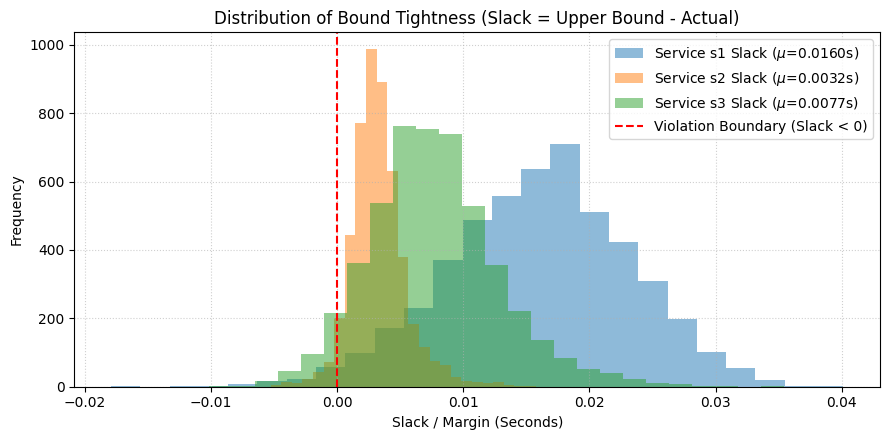

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))

for s_name, s_type in zip(service_names, service_types):
    y_true_test = true_demand(X_test, s_type) + np.random.normal(0, noise_levels[s_name], n_test)
    mu_test, std_test = gp_models[s_name].predict(X_test, return_std=True)

    upper_bound = mu_test + z_score * std_test
    tightness = upper_bound - y_true_test

    ax.hist(tightness, bins=25, alpha=0.5, label=rf"Service {s_name} Slack ($\mu$={np.mean(tightness):.4f}s)")

ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label="Violation Boundary (Slack < 0)")
ax.set_title("Distribution of Bound Tightness (Slack = Upper Bound - Actual)", fontsize=12)
ax.set_xlabel("Slack / Margin (Seconds)")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 6. Node Bounds: the Latency of One Service

Using the predictive mean $\mu_i(x)$ and variance $\sigma_i^2(x)$ from the GP, we evaluate the closed-form Moment
Generating Function (MGF) $M_X(\theta) = \mathbb{E}[e^{\theta X}] = \exp\left(\theta \mu + \frac{\theta^2}{2}\sigma^2\right)$ of the execution time $X$.

**Baseline: a bound on the execution time only.** Chernoff's inequality $P(X \ge D) \le M_X(\theta)\,e^{-\theta D}$ gives
$D = \mu + \sigma\sqrt{2\ln(1/\varepsilon)}$. It ignores the arrival rate $\lambda$ and the queue, so it is not a bound
on latency; it is kept as the baseline "execution time only".

**SNC queueing bound.** An item's latency $W$ at a FIFO server is the largest backlog it finds:
$W = \max_{n \ge 0}\left(\sum_{i=0}^{n} X_i - \sum_{i=1}^{n} T_i\right)$, where the $X_i$ are the execution times of the item and the
$n$ items before it, and the $T_i$ are inter-arrival times. A union bound over $n$ and Chernoff's inequality for each
term give

$$P(W > d) \;\le\; e^{-\theta d}\,\frac{M_X(\theta)}{1 - \rho(\theta)}, \qquad \rho(\theta) = M_X(\theta)\,\mathbb{E}[e^{-\theta T}] < 1,$$

which holds for any i.i.d. inter-arrival times. For Poisson arrivals $\mathbb{E}[e^{-\theta T}] = \lambda / (\lambda + \theta)$;
for periodic arrivals with gaps $T = \frac{1}{\lambda}(1 + U)$, $U \sim \mathcal{U}(-j, j)$, it is
$\mathbb{E}[e^{-\theta T}] = e^{-\theta a}\,\frac{1 - e^{-\theta w}}{\theta w}$ with $a = (1 - j)/\lambda$ and $w = 2j/\lambda$
($e^{-\theta/\lambda}$ for $j = 0$). The latency bound at violation probability $\varepsilon$ is the best $\theta$:
$\;d(\varepsilon) = \min_\theta \frac{1}{\theta}\left[\ln M_X(\theta) - \ln(1 - \rho(\theta)) - \ln \varepsilon\right]$.
For $\lambda \to 0$, $\rho \to 0$ and this is exactly the execution-time bound, i.e. the baseline is the special case of
an empty queue. If $\rho(\theta) \ge 1$ for every $\theta$ (the service is overloaded) there is no finite bound.

**Epistemic uncertainty.** Adding the epistemic variance to every item's variance (Eq. 1 of the paper) treats it as if
it varied from item to item. But epistemic uncertainty is about the *configuration*, not about each item: it is one
unknown shared by all items, and added per item it averages out over the queue. The default therefore uses it as a
confidence level on the mean, $\mu^{+} = \mu + z_{95\%}\,\sigma_{\text{epistemic}}$, with the aleatoric $\sigma_n^2$ as the
item variance. Both treatments are compared in Section 6c.

Sections 6a and 6b give two alternatives to the SNC node bound; Section 6c compares the node bounds on held-out
configurations, and Section 7 composes them.

In [8]:
# Baseline: Chernoff bound on a single execution time, no queue (= the SNC bound with lambda -> 0).
def compute_snc_mgf_delay_bound(model, x_cfg, alpha=0.01):
    """
    Computes the MGF-backed SNC single-node delay bound D_i(x) for target violation prob alpha.

    Using log M_Y(theta) = theta*mu + (theta^2 / 2)*var, Chernoff's bound gives:
    P(Y >= D) <= exp(log M_Y(theta) - theta*D) = alpha
    Solving for optimal theta* yields: theta* = sqrt(-2*ln(alpha) / var)
    Plugging theta* back yields: D_i(alpha) = mu + sqrt(-2*ln(alpha) * var)
    """
    mu, std_total, var_epistemic, var_aleatoric = model.predict(x_cfg, return_variance_components=True)
    var_total = std_total ** 2

    # Node-optimal MGF theta parameter
    theta_opt = np.sqrt(-2.0 * np.log(alpha) / var_total)

    # Closed-form log-MGF evaluated at theta*
    log_mgf_opt = theta_opt * mu + 0.5 * (theta_opt ** 2) * var_total

    # Minimum physical latency bound satisfying target violation probability alpha
    delay_bound = (log_mgf_opt - np.log(alpha)) / theta_opt

    return delay_bound, theta_opt, mu, std_total


# What the bounds believe about the execution time of one item.
def execution_time_belief(model, x_cfg, treatment="confidence"):
    """Returns (mean, item variance) of the execution time.
    'confidence'    : epistemic uncertainty as a confidence level on the mean (default)
    'item_variance' : epistemic variance added to every item's variance (Eq. 1 of the paper)
    'plug_in'       : GP mean and aleatoric variance only"""
    mu, _, var_epistemic, var_aleatoric = model.predict(x_cfg, return_variance_components=True)
    if treatment == "confidence":
        return mu + z_confidence * np.sqrt(var_epistemic), var_aleatoric
    if treatment == "item_variance":
        return mu, var_epistemic + var_aleatoric
    return mu, var_aleatoric


# The SNC bound itself (snc_latency_bound, log_latency_moment, latency_bound_from_moment) and the bounds of
# Sections 6a and 6b are in snc_bounds.py.
print("Node bound functions ready.")

Node bound functions ready.


### 6a. Node Bound with Propagated Arrival Models

The SNC node bound above assumes that its node receives the *external* arrivals. That is true for the first
node only: node $k \ge 2$ receives the departures of node $k-1$. The propagated node bound bounds those departures instead
of reusing the external arrival process. Composed like the other node bounds (Section 7), it gives the **propagated
PPG** (`propagated_node_bounds` in `snc_bounds.py`).

Let $A_n$ be the time between the arrivals of item $i-n$ and item $i$ at node $k$, i.e. between their departures from
node $k-1$. Write $X'$ for execution times and $W'$ for latencies at node $k-1$, and $A'_n$ for the same span at the
*input* of node $k-1$. Two lower bounds hold on every sample path:

1. **Service spacing:** node $k-1$ serves one item at a time, so $A_n \ge X'_{i-n+1} + \dots + X'_i$.
2. **Arrival spacing:** item $i$ leaves node $k-1$ no earlier than its arrival plus its execution time, and item
   $i-n$ leaves exactly at its arrival plus its latency, so $A_n \ge A'_n + X'_i - W'_{i-n}$.

Hence $\mathbb{E}[e^{-\theta A_n}] \le \min\big(M_{X'}(-\theta)^n,\; \mathbb{E}[e^{-\theta A'_n}]\,M_{X'}(-\theta)\,\mathbb{E}[e^{\theta W'}],\; 1\big)$,
where $\mathbb{E}[e^{\theta W'}]$ is the moment that node $k-1$'s own bound already computes. Node $k$'s bound is the
union/Chernoff sum of Section 6 with this spacing in place of the external one:
$P(W > d) \le e^{-\theta d} \sum_n M_X(\theta)^{n+1}\,\mathbb{E}[e^{-\theta A_n}]$.

Bound 1 removes the double counting: a node behind a slower node almost never queues, and its bound now reflects
that. Bound 2 carries the external arrival rate along the chain; it is needed where a node is slower than the node
before it.

**Assumptions beyond those of the PPG:**
- A node's execution times are independent of the spacing of its arrivals. For bound 1, positive correlation between
  an item's execution times at consecutive nodes makes this conservative: the difference of two positively
  correlated Gaussians has a smaller variance than that of two independent ones.
- The latency of item $i-n$ at node $k-1$ is independent of the arrival spacing after it. This is exact directly
  behind the external source (renewal arrivals) and an assumption further down. The simulated coverage in Sections 7
  and 9 tests it.

**Not added: referencing the slowest upstream node directly** (paying the latency of the nodes in between once).
Bound 2 already reaches back through the chain in the same way, and in prototype runs the direct reference never
gave a tighter bound. The remaining looseness in long chains comes from nodes that are as slow as an earlier node
(for example $s_1$ repeated in Section 9): the guaranteed spacing then has no margin, and no spacing argument helps.

### 6b. Martingale Node Bound

The SNC node bound of Section 6 is loose mainly because of its last step: a Chernoff bound with one $\theta$,
which pays $\ln(1/\varepsilon)/\theta$ and a factor $1/(1-\rho(\theta))$ and cannot use that most items don't wait
(see `why_poisson_is_loose.ipynb`). The martingale bound replaces that step. Every node assumes the external arrival process, exactly like the SNC node
bound. Composed like the other node bounds (Section 7), it gives the **martingale PPG** (`martingale_node_bound` in
`snc_bounds.py`).

Write $Q$ for the waiting time of an item at a node (latency minus its own execution time $X$), $T$ for the gap
between arrivals, and $\theta^*$ for the decay rate of the waiting-time tail, the largest $\theta$ with
$\rho(\theta) = M_X(\theta)\,\mathbb{E}[e^{-\theta T}] \le 1$.

1. **Waiting time, any renewal arrivals (Kingman's martingale bound):** $e^{\theta^* (X_1 - T_1 + \dots + X_n - T_n)}$ is a
   martingale over $n$, which gives $P(Q > w) \le e^{-\theta^* w}$. Unlike Section 6 there is no sum over $n$ and no
   $1/(1-\rho)$ factor.
2. **Waiting time, Poisson arrivals (refinement):** by Pollaczek–Khinchine, $Q$ is 0 with probability $1-\rho$ and
   otherwise a sum of residual execution times. Splitting off the first of them and applying step 1 to the rest gives
   $P(Q > w) \le \lambda \int_0^\infty P(X > x)\,\min\big(1, e^{-\theta^*(w - x)}\big)\,dx$, which is at most $\rho$ at
   $w = 0$: the bound now starts at the share of items that wait, not at 1.
3. **Latency:** $Q$ depends only on earlier items, so it is independent of the item's own $X$, and
   $P(Q + X > d) = \mathbb{E}_X\big[P(Q > d - X)\big]$ is computed directly (no second Chernoff step). The expectation is
   evaluated on equal-probability bins of $X$ at each bin's upper edge, with the last bin counted as a violation, so
   the discretization can only make the bound larger.

$\theta^*$ is taken from the same $\theta$ grid as Section 6, as the largest grid value below the first crossing of
$\rho(\theta) = 1$; any $\theta \le \theta^*$ keeps both bounds valid. $X$ is the same belief as for the PPG
(confidence treatment: mean shifted by the epistemic uncertainty, aleatoric variance).

**Assumptions:** the same as the PPG (every node sees the external arrival process), plus renewal arrivals for step 1
and Poisson arrivals for step 2. For periodic arrivals, only step 1 is used.

## 6c. Node Bounds on Held-Out Configurations (RQ1)

For random test configurations, we simulate each service alone as a queue at rate $\lambda$ and compare its measured
$(1-\varepsilon)$ latency quantile with each node bound. *Coverage* is the share of configurations whose measured
quantile is at or below the bound; *tightness* is the median of bound ÷ measured quantile.

The SNC bound is shown with the three treatments of epistemic uncertainty; the martingale bound (6b) uses the default
(confidence) treatment. The execution-time bound is included to show what it misses. The propagated bound (6a) is
identical to the SNC bound for a single service, which has no upstream node.

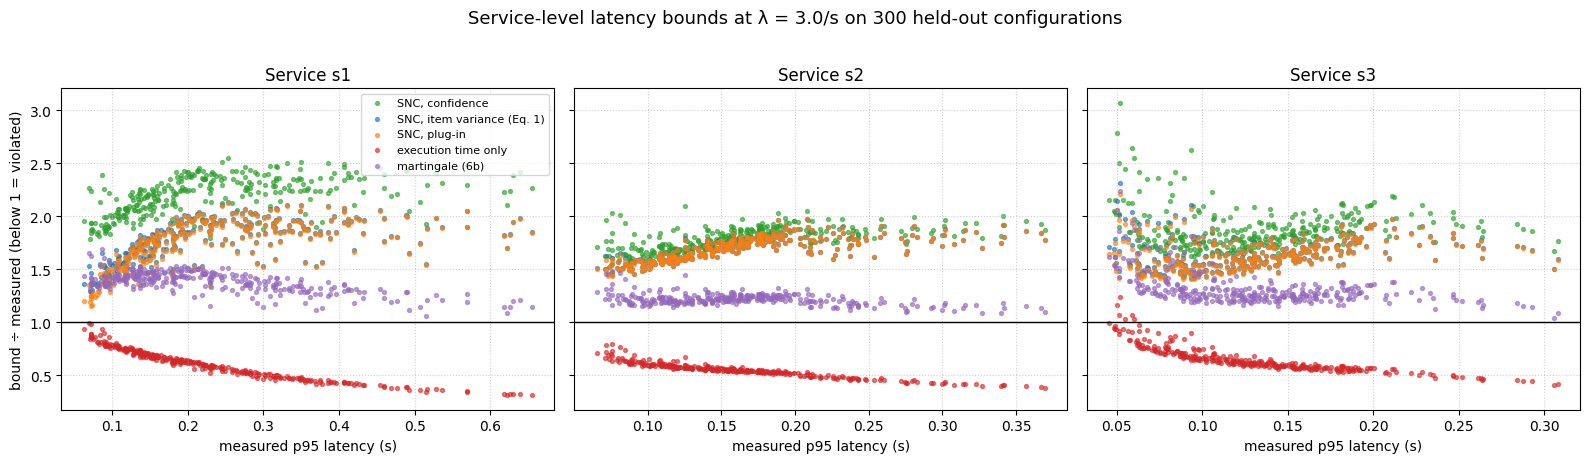

service  bound                         coverage  tightness
s1       SNC, confidence                 100.0%      2.23x
s1       SNC, item variance (Eq. 1)      100.0%      1.81x
s1       SNC, plug-in                    100.0%      1.80x
s1       execution time only               0.0%      0.62x
s1       martingale (6b)                 100.0%      1.40x
s2       SNC, confidence                 100.0%      1.80x
s2       SNC, item variance (Eq. 1)      100.0%      1.70x
s2       SNC, plug-in                    100.0%      1.70x
s2       execution time only               0.0%      0.55x
s2       martingale (6b)                 100.0%      1.21x
s3       SNC, confidence                 100.0%      1.84x
s3       SNC, item variance (Eq. 1)      100.0%      1.63x
s3       SNC, plug-in                    100.0%      1.62x
s3       execution time only               2.0%      0.62x
s3       martingale (6b)                 100.0%      1.27x


In [9]:
rng_nodes = np.random.default_rng(7)

n_cfg_test = 300

X_cfg_test = np.column_stack([
    rng_nodes.uniform(0.5, 2.0, n_cfg_test),
    rng_nodes.uniform(0.5, 2.0, n_cfg_test),
    rng_nodes.uniform(1.0, 4.0, n_cfg_test)
])

single_node_results = {}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, s_name, s_type in zip(axes, service_names, service_types):
    _, latency = simulate_pipeline(X_cfg_test, [s_type], [noise_levels[s_name]], n_sim_items, item_correlation, rng_nodes, workload)
    measured = quantile_per_config(latency)

    beliefs = {treatment: execution_time_belief(gp_models[s_name], X_cfg_test, treatment) for treatment in ("confidence", "item_variance", "plug_in")}
    bounds = {"SNC, confidence": snc_latency_bound(*beliefs["confidence"], epsilon=alpha, **workload),
              "SNC, item variance (Eq. 1)": snc_latency_bound(*beliefs["item_variance"], epsilon=alpha, **workload),
              "SNC, plug-in": snc_latency_bound(*beliefs["plug_in"], epsilon=alpha, **workload),
              "execution time only": compute_snc_mgf_delay_bound(gp_models[s_name], X_cfg_test, alpha=alpha)[0],
              "martingale (6b)": martingale_node_bound(*beliefs["confidence"], epsilon=alpha, **workload)}
    for name, bound in bounds.items():
        single_node_results[(s_name, name)] = {"coverage": np.mean(measured <= bound), "tightness": np.median(bound / measured)}

    for (name, bound), color in zip(bounds.items(), ["tab:green", "tab:blue", "tab:orange", "tab:red", "tab:purple"]):
        ax.scatter(measured, bound / measured, s=8, alpha=0.6, color=color, label=name)
    ax.axhline(1.0, color="black", linewidth=1)
    ax.set_title(f"Service {s_name}")
    ax.set_xlabel(f"measured p{p_str} latency (s)")
    ax.grid(True, linestyle=":", alpha=0.6)
axes[0].set_ylabel("bound ÷ measured (below 1 = violated)")
axes[0].legend(fontsize=8)
plt.suptitle(f"Service-level latency bounds at λ = {arrival_rate}/s on {n_cfg_test} held-out configurations", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"{'service':<8} {'bound':<28} {'coverage':>9} {'tightness':>10}")
for (s_name, name), result in single_node_results.items():
    print(f"{s_name:<8} {name:<28} {result['coverage']:>9.1%} {result['tightness']:>9.2f}x")

In [10]:
across = lambda name, key: [single_node_results[(s_name, name)][key] for s_name in service_names]
snc_treatments = ["SNC, confidence", "SNC, item variance (Eq. 1)", "SNC, plug-in"]
display(Markdown(
    "**What this shows.**\n"
    f"- **The execution-time bound is not a latency bound.** It covers {span(across('execution time only', 'coverage'), pct)} "
    "of the configurations per service, because it leaves out the queue.\n"
    f"- **The SNC queueing bound** covers {span([c for t in snc_treatments for c in across(t, 'coverage')], pct)} of the "
    f"configurations under all three treatments of epistemic uncertainty. Its tightness is "
    f"{span(across('SNC, confidence', 'tightness'), ratio)} with the confidence treatment, "
    f"{span(across('SNC, item variance (Eq. 1)', 'tightness'), ratio)} with Eq. (1) and "
    f"{span(across('SNC, plug-in', 'tightness'), ratio)} with the plug-in: the epistemic variance per item averages out "
    "in the queue, while the confidence treatment shifts the mean that every item shares and is the only one that "
    "responds to how much the GP knows about a configuration.\n"
    f"- **The martingale bound (6b)**, with the confidence treatment, covers {span(across('martingale (6b)', 'coverage'), pct)} "
    f"of the configurations with tightness {span(across('martingale (6b)', 'tightness'), ratio)}."))

**What this shows.**
- **The execution-time bound is not a latency bound.** It covers between 0% and 2% of the configurations per service, because it leaves out the queue.
- **The SNC queueing bound** covers 100% of the configurations under all three treatments of epistemic uncertainty. Its tightness is between 1.80× and 2.23× with the confidence treatment, between 1.63× and 1.81× with Eq. (1) and between 1.62× and 1.80× with the plug-in: the epistemic variance per item averages out in the queue, while the confidence treatment shifts the mean that every item shares and is the only one that responds to how much the GP knows about a configuration.
- **The martingale bound (6b)**, with the confidence treatment, covers 100% of the configurations with tightness between 1.21× and 1.40×.

## 7. Composition & End-to-End Performance Analysis

**The union bound is the PPG.** A request violates the end-to-end bound $\sum_k d_k$ only if it
violates at least one node bound $d_k$. So if every node bound is computed at $\varepsilon / K$ for a path of $K$ nodes,

$$P\Big(\sum_k W_k > \sum_k d_k(\varepsilon / K)\Big) \;\le\; \sum_k P\big(W_k > d_k(\varepsilon / K)\big) \;\le\; \varepsilon,$$

whatever the dependence between the services. For a DAG, the budget is split over all nodes and the bound is the
longest path. The same composition applied to the node bounds of Sections 6a and 6b gives the **propagated PPG** and
the **martingale PPG**.

**Composition by independence (baseline):** adding the means and variances and optimizing one $\theta$ multiplies the
node MGFs, which is only valid if the nodes are *independent*. The same holds for its queueing version below.
In this pipeline they are not independent: an item that is large at $s_1$ is large at $s_2$ and $s_3$, and queues
propagate downstream.

*Why SNC and not the joint Gaussian?* if execution times were Gaussian and independent, the
joint Gaussian quantile would be exact and any Chernoff bound would be looser ($\sqrt{2\ln(1/\varepsilon)} = 2.45$ vs
$z = 1.64$ standard deviations at $\varepsilon = 0.05$). That is why the SNC bound on execution times comes out above the naive sum. SNC
earns its place because it (1) bounds queueing latency from the MGF, which has no closed-form quantile, and (2)
composes with the union bound without assuming independence.

In [11]:
# Nominal operating point
x_pipeline_cfg = np.array([[1.0, 1.0, 2.0]])  # [CPU, Quality, Parallelism]
n_nodes = len(service_names)

# ------------------------------------------------------------------------------
# A. Node-level bounds
# ------------------------------------------------------------------------------
node_mus = []
node_stds = []
node_delays = []   # execution-time-only bounds (baseline), in seconds
node_beliefs = []  # (mean, item variance) under the confidence treatment

print("\n=== Individual Node Performance Guarantees ===")
for s_name in service_names:
    model = gp_models[s_name]

    # Predict mean and standard deviation
    mu, std = model.predict(x_pipeline_cfg, return_std=True)

    # baseline: bound on the execution time only (no queue)
    delay, _, _, _ = compute_snc_mgf_delay_bound(model, x_pipeline_cfg, alpha=alpha)

    # SNC latency bounds with queueing, at the full budget epsilon and at the PPG share epsilon / K
    belief = execution_time_belief(model, x_pipeline_cfg, "confidence")
    latency_full = snc_latency_bound(*belief, epsilon=alpha, **workload)[0]
    latency_share = snc_latency_bound(*belief, epsilon=alpha / n_nodes, **workload)[0]

    node_mus.append(mu[0])
    node_stds.append(std[0])
    node_delays.append(delay[0])
    node_beliefs.append(belief)

    print(
        f"Service {s_name:2s} | "
        f"Pred exec time = {mu[0]:.4f}s (std = {std[0]:.4f}) | "
        f"exec-time bound = {delay[0]:.4f}s | "
        f"SNC latency bound at ε = {latency_full:.4f}s, at ε/K = {latency_share:.4f}s"
    )


=== Individual Node Performance Guarantees ===
Service s1 | Pred exec time = 0.0808s (std = 0.0100) | exec-time bound = 0.1053s | SNC latency bound at ε = 0.3351s, at ε/K = 0.3901s
Service s2 | Pred exec time = 0.0723s (std = 0.0016) | exec-time bound = 0.0763s | SNC latency bound at ε = 0.2347s, at ε/K = 0.2727s
Service s3 | Pred exec time = 0.0587s (std = 0.0045) | exec-time bound = 0.0696s | SNC latency bound at ε = 0.1891s, at ε/K = 0.2195s


In [12]:
# ------------------------------------------------------------------------------
# B. Baseline: composition of execution times (independent, no queue)
# ------------------------------------------------------------------------------
mu_total = sum(node_mus)
var_total = sum(std ** 2 for std in node_stds)
std_total = np.sqrt(var_total)

# Global optimal theta* for end-to-end composition variance
theta_opt = np.sqrt(2 * -np.log(alpha) / var_total)

# E2E Log-MGF sum
e2e_log_mgf_opt = theta_opt * mu_total + 0.5 * (theta_opt ** 2) * var_total

# Physical latency bound (seconds)
e2e_latency_bound_opt = (e2e_log_mgf_opt - np.log(alpha)) / theta_opt

# ------------------------------------------------------------------------------
# C. Compositions of latency bounds (with queueing)
# ------------------------------------------------------------------------------
# PPG: union bound, every node at epsilon / K. Valid for any dependence between nodes.
ppg_bound = sum(snc_latency_bound(*belief, epsilon=alpha / n_nodes, **workload)[0] for belief in node_beliefs)
# PPG with propagated arrival models (Section 6a)
propagated_bound = propagated_node_bounds(node_beliefs, epsilon=alpha / n_nodes, **workload).sum()
# PPG with martingale node bounds (Section 6b)
martingale_bound = sum(martingale_node_bound(*belief, epsilon=alpha / n_nodes, **workload)[0] for belief in node_beliefs)
# Additive: every node at epsilon, without splitting. Common practice, no guarantee.
additive_bound = sum(snc_latency_bound(*belief, epsilon=alpha, **workload)[0] for belief in node_beliefs)
# Independent SNC convolution: multiply the node latency MGFs, one theta. Needs independent nodes.
independent_bound = latency_bound_from_moment(sum(log_latency_moment(*belief, **workload) for belief in node_beliefs), alpha)[0]

# ------------------------------------------------------------------------------
# D. Ground truth
# ------------------------------------------------------------------------------
# Baseline ground truth: sum of independent execution times, no queue
n_samples = 100_000
rng_no_queue = np.random.RandomState(42)
simulated_latencies = np.zeros(n_samples)
for s_name, s_type in zip(service_names, service_types):
    true_latent = true_demand(x_pipeline_cfg, s_type)[0]
    simulated_latencies += rng_no_queue.normal(true_latent, noise_levels[s_name], n_samples)

oracle_real_p_latency = np.percentile(simulated_latencies, (1 - alpha) * 100)

# Ground truth: the queueing pipeline (Section 1b)
rng_nominal = np.random.default_rng(42)
nominal_node_latencies, nominal_latencies = simulate_pipeline(
    np.repeat(x_pipeline_cfg, 20, axis=0), service_types, [noise_levels[s] for s in service_names],
    n_sim_items, item_correlation, rng_nominal, workload)
oracle_queueing_p_latency = np.quantile(nominal_latencies, 1 - alpha)

# Is independence a safe assumption? Shuffle each node's latencies across items, which keeps every node's
# distribution but removes the dependence, and compare the resulting quantile with the real one.
independent_latencies = sum(rng_nominal.permuted(nominal_node_latencies[:, :, k], axis=1) for k in range(n_nodes))
oracle_independent_p_latency = np.quantile(independent_latencies, 1 - alpha)

# ------------------------------------------------------------------------------
# E. Summary
# ------------------------------------------------------------------------------
b1_sum_of_means = mu_total
b2_naive_sum_p = sum(m + z_score * s for m, s in zip(node_mus, node_stds))   # epsilon at every node (no split)
b3_joint_gaussian_p = mu_total + z_score * std_total                         # assumes independence
b4_snc_mgf_bound = e2e_latency_bound_opt
b5_oracle_real_p = oracle_real_p_latency

print("\n" + "=" * 100)
print(f"{'E2E LATENCY BOUND COMPARISON (epsilon = ' + str(alpha) + ', lambda = ' + str(arrival_rate) + '/s, ' + arrival_process + ' arrivals)':^100}")
print("=" * 100)
print(f"{'Method / Baseline':<42} | {'Latency (s)':<11} | {'Notes / Interpretation'}")
print("-" * 100)
print("Execution times only (no queue)")
print(f"{'  1. Sum of Means (E[Y])':<42} | {b1_sum_of_means:<11.4f} | Mean execution time only (no tail risk)")
print(f"{f'  2. Naive Sum of p{p_str} Exec. Times':<42} | {b2_naive_sum_p:<11.4f} | Epsilon at every node")
print(f"{f'  3. Joint Gaussian {p_str}% Quantile':<42} | {b3_joint_gaussian_p:<11.4f} | Assumes independence")
print(f"{'  4. SNC MGF Bound on Exec. Times':<42} | {b4_snc_mgf_bound:<11.4f} | Assumes independence")
print(f"{f'  5. Oracle p{p_str}, independent, no queue':<42} | {b5_oracle_real_p:<11.4f} | Baseline ground truth")
print("-" * 100)
print("Latency bounds (with queueing)")
print(f"{'  Additive latency bounds (epsilon each)':<42} | {additive_bound:<11.4f} | No guarantee: budget not split")
print(f"{'  Independent SNC convolution':<42} | {independent_bound:<11.4f} | No guarantee: assumes independence")
print(f"{'  PPG: union bound (epsilon / K each)':<42} | {ppg_bound:<11.4f} | Guarantee for any dependence")
print(f"{'  PPG, propagated arrivals (6a)':<42} | {propagated_bound:<11.4f} | Union bound; node k fed by node k-1")
print(f"{'  PPG, martingale node bounds (6b)':<42} | {martingale_bound:<11.4f} | Union bound; martingale per node")
print("-" * 100)
print("Ground truth (queueing pipeline)")
print(f"{f'  Oracle p{p_str}':<42} | {oracle_queueing_p_latency:<11.4f} | Simulated end-to-end latency")
print(f"{f'  Oracle p{p_str}, nodes made independent':<42} | {oracle_independent_p_latency:<11.4f} | Same node latencies, dependence removed")
print("=" * 100)


          E2E LATENCY BOUND COMPARISON (epsilon = 0.05, lambda = 3.0/s, poisson arrivals)           
Method / Baseline                          | Latency (s) | Notes / Interpretation
----------------------------------------------------------------------------------------------------
Execution times only (no queue)
  1. Sum of Means (E[Y])                   | 0.2118      | Mean execution time only (no tail risk)
  2. Naive Sum of p95 Exec. Times          | 0.2383      | Epsilon at every node
  3. Joint Gaussian 95% Quantile           | 0.2300      | Assumes independence
  4. SNC MGF Bound on Exec. Times          | 0.2389      | Assumes independence
  5. Oracle p95, independent, no queue     | 0.2215      | Baseline ground truth
----------------------------------------------------------------------------------------------------
Latency bounds (with queueing)
  Additive latency bounds (epsilon each)   | 0.7589      | No guarantee: budget not split
  Independent SNC convolution           

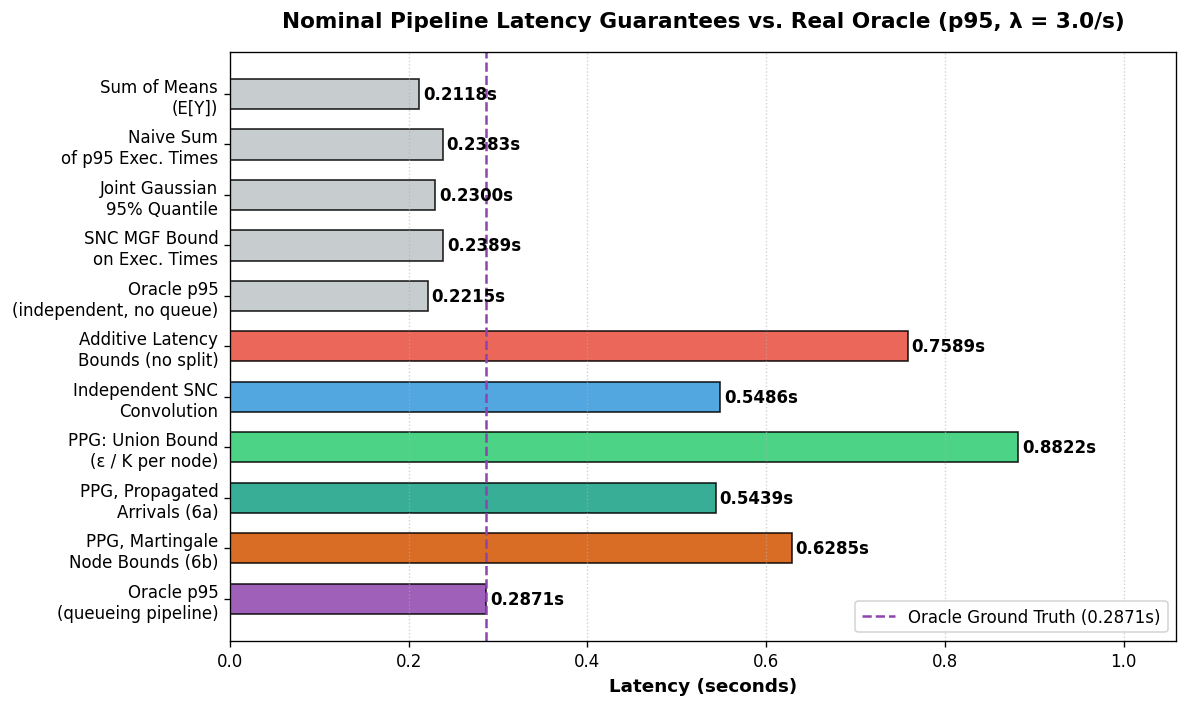

In [13]:
# ------------------------------------------------------------------------------
# E. Visualization: Nominal Configuration Bar Chart
# ------------------------------------------------------------------------------
# grey: execution times only (no queue); colored: latency bounds; purple: ground truth
labels = [
    'Sum of Means\n(E[Y])',
    f'Naive Sum\nof p{p_str} Exec. Times',
    f'Joint Gaussian\n{p_str}% Quantile',
    'SNC MGF Bound\non Exec. Times',
    f'Oracle p{p_str}\n(independent, no queue)',
    'Additive Latency\nBounds (no split)',
    'Independent SNC\nConvolution',
    'PPG: Union Bound\n(ε / K per node)',
    'PPG, Propagated\nArrivals (6a)',
    'PPG, Martingale\nNode Bounds (6b)',
    f'Oracle p{p_str}\n(queueing pipeline)'
]
values = [
    b1_sum_of_means,
    b2_naive_sum_p,
    b3_joint_gaussian_p,
    b4_snc_mgf_bound,
    b5_oracle_real_p,
    additive_bound,
    independent_bound,
    ppg_bound,
    propagated_bound,
    martingale_bound,
    oracle_queueing_p_latency
]
colors = ['#bdc3c7'] * 5 + ['#e74c3c', '#3498db', '#2ecc71', '#16a085', '#d35400', '#8e44ad']

plt.figure(figsize=(10, 6), dpi=120)
bars = plt.barh(labels, values, color=colors, edgecolor='black', alpha=0.85, height=0.6)

plt.axvline(
    x=oracle_queueing_p_latency,
    color='#8e44ad',
    linestyle='--',
    linewidth=1.5,
    label=f'Oracle Ground Truth ({oracle_queueing_p_latency:.4f}s)'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.004,
        bar.get_y() + bar.get_height()/2,
        f'{width:.4f}s',
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold'
    )

plt.xlim(0, max(values) * 1.2)
plt.xlabel('Latency (seconds)', fontsize=11, fontweight='bold')
plt.title(
    f'Nominal Pipeline Latency Guarantees vs. Real Oracle (p{p_str}, λ = {arrival_rate}/s)',
    fontsize=13,
    fontweight='bold',
    pad=15
)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

In [14]:
no_queue = [b1_sum_of_means, b2_naive_sum_p, b3_joint_gaussian_p, b4_snc_mgf_bound, b5_oracle_real_p]
guaranteed = {"PPG": ppg_bound, "propagated PPG (6a)": propagated_bound, "martingale PPG (6b)": martingale_bound}
truth = oracle_queueing_p_latency
shift = oracle_independent_p_latency - truth
display(Markdown(
    "**What this shows.**\n"
    f"- **Execution-time baselines (grey):** {sum(v < truth for v in no_queue)} of {len(no_queue)} fall below the "
    f"simulated p{p_str} of {truth:.3f} s. They describe execution times, not latencies.\n"
    "- **Guarantees:** " + ", ".join(f"{name} {value:.3f} s ({ratio(value / truth)})" for name, value in guaranteed.items())
    + f" the simulated p{p_str}. The tightest guarantee here is the {min(guaranteed, key=guaranteed.get)}.\n"
    f"- **No guarantee:** the additive bounds ({ratio(additive_bound / truth)}) use $\\varepsilon$ at every node, the "
    f"independent SNC convolution ({ratio(independent_bound / truth)}) assumes independent nodes.\n"
    f"- **Independence check:** removing the dependence between the simulated node latencies moves the p{p_str} "
    f"{'down' if shift < 0 else 'up'} by {abs(shift) * 1000:.1f} ms, so assuming independence "
    f"{'under' if shift < 0 else 'over'}-estimates the tail here (Section 9 shows how this grows with depth)."))

**What this shows.**
- **Execution-time baselines (grey):** 5 of 5 fall below the simulated p95 of 0.287 s. They describe execution times, not latencies.
- **Guarantees:** PPG 0.882 s (3.07×), propagated PPG (6a) 0.544 s (1.89×), martingale PPG (6b) 0.628 s (2.19×) the simulated p95. The tightest guarantee here is the propagated PPG (6a).
- **No guarantee:** the additive bounds (2.64×) use $\varepsilon$ at every node, the independent SNC convolution (1.91×) assumes independent nodes.
- **Independence check:** removing the dependence between the simulated node latencies moves the p95 down by 0.7 ms, so assuming independence under-estimates the tail here (Section 9 shows how this grows with depth).

## 8. Design Space Sensitivity & Sweep Analysis

To check that the bounds hold across different allocations, we sweep CPU availability and quality over the training
range while tracking bound tightness and pessimism. The bound is the PPG (union bound over SNC node bounds) and the
oracle is the simulated queueing pipeline; tightness is the ratio PPG ÷ measured p95. Its variants from Sections 6a
and 6b are compared in Sections 7 and 9. The simulation is vectorized over the grid and takes a few seconds.

PPG coverage over the grid: 100.0% of 1225 configurations; tightness median 3.17x (range 2.78x – 3.79x)


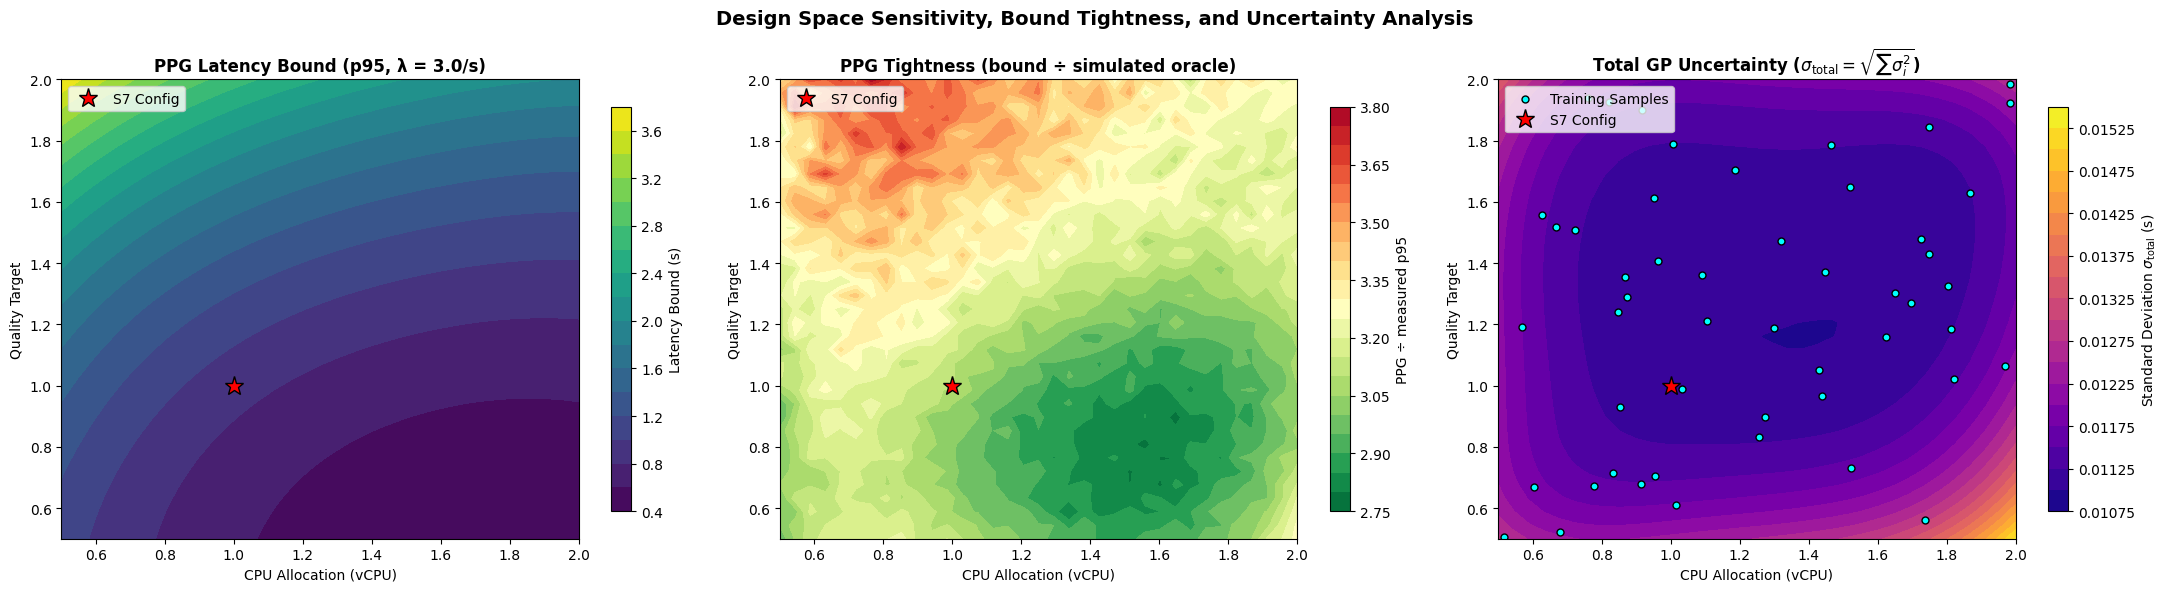

In [15]:
# ------------------------------------------------------------------------------
# A. Build 2D Meshgrid & Storage Matrices
# ------------------------------------------------------------------------------
n_sweep = 35  # 35 x 35 = 1,225 evaluation points
cpu_axis = np.linspace(0.5, 2.0, n_sweep)
quality_axis = np.linspace(0.5, 2.0, n_sweep)

CPU_grid, QUALITY_grid = np.meshgrid(cpu_axis, quality_axis)
PARALLELISM_grid = np.full_like(CPU_grid, 2.0)

# Flatten grid for batched GP predictions
X_2d_sweep = np.column_stack([
    CPU_grid.ravel(),
    QUALITY_grid.ravel(),
    PARALLELISM_grid.ravel()
])

# ------------------------------------------------------------------------------
# B. Evaluate PPG Bounds, Oracle Ground Truth & Uncertainty (vectorized)
# ------------------------------------------------------------------------------
sweep_beliefs = [execution_time_belief(gp_models[s_name], X_2d_sweep, "confidence") for s_name in service_names]
ppg_surface = sum(snc_latency_bound(*belief, epsilon=alpha / n_nodes, **workload) for belief in sweep_beliefs)

std_total_surface = np.sqrt(sum(gp_models[s_name].predict(X_2d_sweep, return_std=True)[1] ** 2 for s_name in service_names))

rng_sweep = np.random.default_rng(42)
_, sweep_latencies = simulate_pipeline(X_2d_sweep, service_types, [noise_levels[s] for s in service_names],
                                       n_sim_items, item_correlation, rng_sweep, workload)
oracle_surface = quantile_per_config(sweep_latencies)
ratio_surface = ppg_surface / oracle_surface

print(f"PPG coverage over the grid: {np.mean(oracle_surface <= ppg_surface):.1%} of {len(X_2d_sweep)} configurations; "
      f"tightness median {np.median(ratio_surface):.2f}x (range {ratio_surface.min():.2f}x – {ratio_surface.max():.2f}x)")

# Reshape flattened results back to 2D matrix shape
PPG_matrix = ppg_surface.reshape(n_sweep, n_sweep)
Ratio_matrix = ratio_surface.reshape(n_sweep, n_sweep)
Std_Total_matrix = std_total_surface.reshape(n_sweep, n_sweep)

# ------------------------------------------------------------------------------
# C. Side-by-Side Unified Plotting (1 Row x 3 Columns - Clean 2D Grid)
# ------------------------------------------------------------------------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6), dpi=100)

# S7 nominal configuration point
s7_cpu = x_pipeline_cfg[0, 0]
s7_quality = x_pipeline_cfg[0, 1]
s7_label = f'S7 Config'

# Subplot 1: Absolute Latency Bound Surface (2D Contour)
c1 = ax1.contourf(CPU_grid, QUALITY_grid, PPG_matrix, levels=20, cmap='viridis')
fig.colorbar(c1, ax=ax1, shrink=0.88, label='Latency Bound (s)')
ax1.plot(s7_cpu, s7_quality, 'r*', markersize=14, markeredgecolor='black', label=s7_label)
ax1.set_title(f'PPG Latency Bound (p{p_str}, λ = {arrival_rate}/s)', fontsize=12, fontweight='bold')
ax1.set_xlabel('CPU Allocation (vCPU)', fontsize=10)
ax1.set_ylabel('Quality Target', fontsize=10)
ax1.legend(loc='upper left', frameon=True)

# Subplot 2: tightness ratio; the dashed line marks ratio 1 (violation below it)
c2 = ax2.contourf(CPU_grid, QUALITY_grid, Ratio_matrix, levels=20, cmap='RdYlGn_r')
fig.colorbar(c2, ax=ax2, shrink=0.88, label='PPG ÷ measured p95')
ax2.plot(s7_cpu, s7_quality, 'r*', markersize=14, markeredgecolor='black', label=s7_label)
if Ratio_matrix.min() < 1.0:
    contour_one = ax2.contour(CPU_grid, QUALITY_grid, Ratio_matrix, levels=[1.0], colors='black', linewidths=2.0, linestyles='--')
    ax2.clabel(contour_one, inline=True, fmt='violation', fontsize=9)
ax2.set_title('PPG Tightness (bound ÷ simulated oracle)', fontsize=12, fontweight='bold')
ax2.set_xlabel('CPU Allocation (vCPU)', fontsize=10)
ax2.set_ylabel('Quality Target', fontsize=10)
ax2.legend(loc='upper left', frameon=True)

# Subplot 3: Total GP Uncertainty Surface (2D Contour - Perfectly Aligned)
c3 = ax3.contourf(CPU_grid, QUALITY_grid, Std_Total_matrix, levels=20, cmap='plasma')
fig.colorbar(c3, ax=ax3, shrink=0.88, label=r'Standard Deviation $\sigma_{\mathrm{total}}$ (s)')

# Scatter training data points
ax3.scatter(X_train[:, 0], X_train[:, 1], color='cyan', edgecolors='black', s=25, label='Training Samples')

# Plot S7 point
ax3.plot(s7_cpu, s7_quality, 'r*', markersize=14, markeredgecolor='black', label=s7_label)

ax3.set_title(r'Total GP Uncertainty ($\sigma_{\mathrm{total}} = \sqrt{\sum \sigma_i^2}$)', fontsize=12, fontweight='bold')
ax3.set_xlabel('CPU Allocation (vCPU)', fontsize=10)
ax3.set_ylabel('Quality Target', fontsize=10)
ax3.legend(loc='upper left', frameon=True)

plt.suptitle("Design Space Sensitivity, Bound Tightness, and Uncertainty Analysis", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 9. Composition vs. Depth (RQ2)

Chains of $K$ services, cycling through $s_1, s_2, s_3$ (every node has its own queue), at random held-out
configurations shared by all nodes (the global-quality assumption). For every depth we compare the PPG and its two
variants (propagated arrivals, 6a; martingale node bounds, 6b) with the two compositions that carry no guarantee, and
with two oracles that use the *measured* node latencies instead of the node bounds: one composes them with the union
bound (this isolates what the union bound itself costs), the other combines them as if they were independent (this
shows directly whether independence is a safe assumption, without any model error).

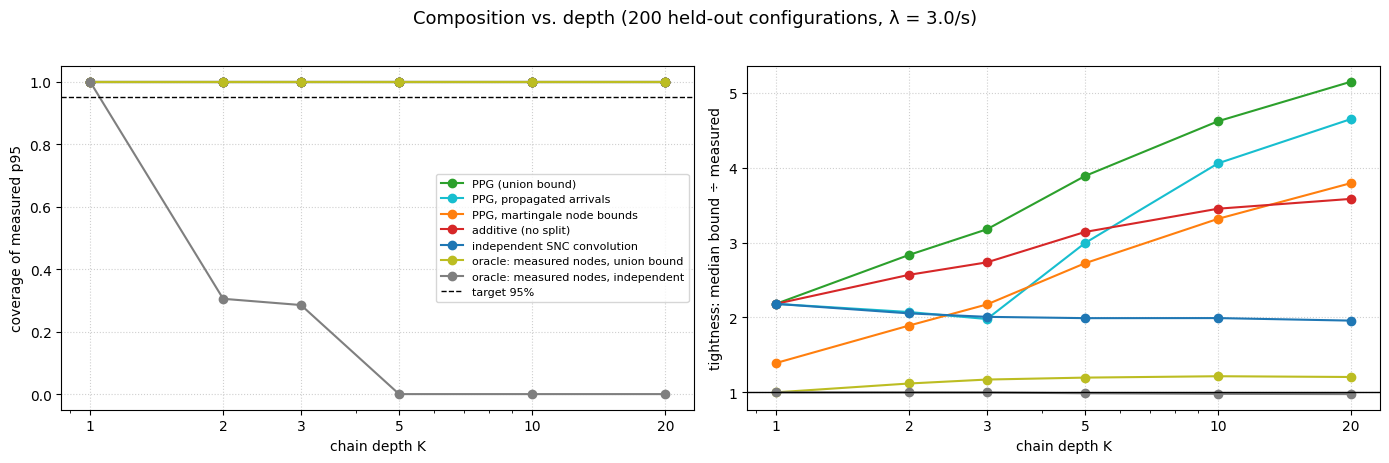

depth composition                             coverage  tightness
    1 PPG (union bound)                         100.0%      2.18x
    1 PPG, propagated arrivals                  100.0%      2.18x
    1 PPG, martingale node bounds               100.0%      1.39x
    1 additive (no split)                       100.0%      2.18x
    1 independent SNC convolution               100.0%      2.18x
    1 oracle: measured nodes, union bound       100.0%      1.00x
    1 oracle: measured nodes, independent       100.0%      1.00x
    2 PPG (union bound)                         100.0%      2.83x
    2 PPG, propagated arrivals                  100.0%      2.07x
    2 PPG, martingale node bounds               100.0%      1.89x
    2 additive (no split)                       100.0%      2.57x
    2 independent SNC convolution               100.0%      2.05x
    2 oracle: measured nodes, union bound       100.0%      1.12x
    2 oracle: measured nodes, independent        30.5%      1.00x
    3 PPG 

In [16]:
depths = [1, 2, 3, 5, 10, 20]
n_cfg_depth = 200
rng_depth = np.random.default_rng(11)
X_cfg_depth = np.column_stack([
    rng_depth.uniform(0.5, 2.0, n_cfg_depth),
    rng_depth.uniform(0.5, 2.0, n_cfg_depth),
    rng_depth.uniform(1.0, 4.0, n_cfg_depth)
])
beliefs_by_service = {s_name: execution_time_belief(gp_models[s_name], X_cfg_depth, "confidence") for s_name in service_names}

depth_rows = []
for depth in depths:
    path = [service_names[k % 3] for k in range(depth)]
    node_latencies, latencies = simulate_pipeline(X_cfg_depth, [service_types[k % 3] for k in range(depth)],
                                                  [noise_levels[s] for s in path], n_sim_items, item_correlation, rng_depth, workload)
    measured = quantile_per_config(latencies)
    shuffled = sum(rng_depth.permuted(node_latencies[:, :, k], axis=1) for k in range(depth))
    martingale_by_service = {s: martingale_node_bound(*beliefs_by_service[s], epsilon=alpha / depth, **workload) for s in set(path)}
    compositions = {
        "PPG (union bound)": sum(snc_latency_bound(*beliefs_by_service[s], epsilon=alpha / depth, **workload) for s in path),
        "PPG, propagated arrivals": propagated_node_bounds([beliefs_by_service[s] for s in path], epsilon=alpha / depth, **workload).sum(axis=0),
        "PPG, martingale node bounds": sum(martingale_by_service[s] for s in path),
        "additive (no split)": sum(snc_latency_bound(*beliefs_by_service[s], epsilon=alpha, **workload) for s in path),
        "independent SNC convolution": latency_bound_from_moment(sum(log_latency_moment(*beliefs_by_service[s], **workload) for s in path), alpha),
        "oracle: measured nodes, union bound": sum(quantile_per_config(node_latencies[:, :, k], 1 - alpha / depth) for k in range(depth)),
        "oracle: measured nodes, independent": quantile_per_config(shuffled),
    }
    for name, bound in compositions.items():
        depth_rows.append({"depth": depth, "composition": name, "coverage": np.mean(measured <= bound), "tightness": np.median(bound / measured)})

fig, (ax_cov, ax_tight) = plt.subplots(1, 2, figsize=(14, 4.5))
for name, color in zip(["PPG (union bound)", "PPG, propagated arrivals", "PPG, martingale node bounds", "additive (no split)", "independent SNC convolution",
                        "oracle: measured nodes, union bound", "oracle: measured nodes, independent"],
                       ["tab:green", "tab:cyan", "tab:orange", "tab:red", "tab:blue", "tab:olive", "tab:gray"]):
    rows = [row for row in depth_rows if row["composition"] == name]
    ax_cov.plot(depths, [row["coverage"] for row in rows], "o-", color=color, label=name)
    ax_tight.plot(depths, [row["tightness"] for row in rows], "o-", color=color, label=name)
ax_cov.axhline(1 - alpha, color="black", linestyle="--", linewidth=1, label=f"target {1 - alpha:.0%}")
ax_cov.set_ylabel(f"coverage of measured p{p_str}")
ax_tight.axhline(1.0, color="black", linewidth=1)
ax_tight.set_ylabel("tightness: median bound ÷ measured")
for ax in (ax_cov, ax_tight):
    ax.set_xscale("log")
    ax.set_xticks(depths, [str(d) for d in depths])
    ax.set_xlabel("chain depth K")
    ax.grid(True, linestyle=":", alpha=0.6)
ax_cov.legend(fontsize=8)
plt.suptitle(f"Composition vs. depth ({n_cfg_depth} held-out configurations, λ = {arrival_rate}/s)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"{'depth':>5} {'composition':<38} {'coverage':>9} {'tightness':>10}")
for row in depth_rows:
    print(f"{row['depth']:>5} {row['composition']:<38} {row['coverage']:>9.1%} {row['tightness']:>9.2f}x")

In [17]:
# how much the propagated arrival models and the martingale node bounds tighten the PPG over depth

row = {(r["depth"], r["composition"]): r for r in depth_rows}
new_methods = ["PPG, propagated arrivals", "PPG, martingale node bounds"]
lines = [f"| {d} | {row[(d, 'PPG (union bound)')]['tightness']:.2f}× | "
         + " | ".join(f"{row[(d, m)]['tightness']:.2f}× ({row[(d, m)]['coverage']:.0%})" for m in new_methods)
         + f" | {row[(d, 'oracle: measured nodes, union bound')]['tightness']:.2f}× |" for d in depths]
display(Markdown(
    "**PPG vs. the new node bounds (Sections 6a, 6b).** Tightness is the median of bound ÷ measured p"
    f"{p_str} over the held-out configurations, coverage in brackets; the oracle column is the best a union bound over "
    "nodes can do.\n\n"
    "| depth | PPG | propagated PPG (6a) | martingale PPG (6b) | oracle: measured nodes, union bound |\n|---|---|---|---|---|\n"
    + "\n".join(lines)))

**PPG vs. the new node bounds (Sections 6a, 6b).** Tightness is the median of bound ÷ measured p95 over the held-out configurations, coverage in brackets; the oracle column is the best a union bound over nodes can do.

| depth | PPG | propagated PPG (6a) | martingale PPG (6b) | oracle: measured nodes, union bound |
|---|---|---|---|---|
| 1 | 2.18× | 2.18× (100%) | 1.39× (100%) | 1.00× |
| 2 | 2.83× | 2.07× (100%) | 1.89× (100%) | 1.12× |
| 3 | 3.18× | 1.98× (100%) | 2.17× (100%) | 1.17× |
| 5 | 3.89× | 2.99× (100%) | 2.72× (100%) | 1.20× |
| 10 | 4.62× | 4.06× (100%) | 3.32× (100%) | 1.22× |
| 20 | 5.15× | 4.65× (100%) | 3.79× (100%) | 1.20× |

In [18]:
guaranteed = ["PPG (union bound)", "PPG, propagated arrivals", "PPG, martingale node bounds"]
deeper = [d for d in depths if d > 1]
independent_coverage = [row[(d, "oracle: measured nodes, independent")]["coverage"] for d in deeper]
deepest = depths[-1]
display(Markdown(
    "**What this shows.**\n"
    "- **Coverage:** the lowest coverage over all depths is "
    + ", ".join(f"{pct(min(row[(d, m)]['coverage'] for d in depths))} for the {m}" for m in guaranteed)
    + f" (target {pct(1 - alpha)}).\n"
    f"- **Independence does not hold.** Combining the *measured* node latencies as if independent covers "
    f"{span(independent_coverage, pct)} of the configurations at depths {deeper[0]}–{deeper[-1]}. The independent SNC "
    "convolution only covers where its node bounds are loose enough; it gives no guarantee.\n"
    f"- **The slack comes from the node bounds, not from the union bound.** At depth {deepest}, composing the measured "
    f"node latencies with the union bound is {ratio(row[(deepest, 'oracle: measured nodes, union bound')]['tightness'])} the "
    f"measured p{p_str}, the PPG {ratio(row[(deepest, 'PPG (union bound)')]['tightness'])}. The propagated arrival models "
    "(6a) remove the part of the slack that comes from counting the external bursts again at every downstream node; the "
    "martingale node bounds (6b) remove part of the slack of every single node bound. The table above shows which of "
    "the two is tighter at which depth."))

**What this shows.**
- **Coverage:** the lowest coverage over all depths is 100% for the PPG (union bound), 100% for the PPG, propagated arrivals, 100% for the PPG, martingale node bounds (target 95%).
- **Independence does not hold.** Combining the *measured* node latencies as if independent covers between 0% and 30% of the configurations at depths 2–20. The independent SNC convolution only covers where its node bounds are loose enough; it gives no guarantee.
- **The slack comes from the node bounds, not from the union bound.** At depth 20, composing the measured node latencies with the union bound is 1.20× the measured p95, the PPG 5.15×. The propagated arrival models (6a) remove the part of the slack that comes from counting the external bursts again at every downstream node; the martingale node bounds (6b) remove part of the slack of every single node bound. The table above shows which of the two is tighter at which depth.

## Changelog (2026-09-30)

Each change is described in the section it touches; the earlier code is in the git history.

| # | change | why |
|---|---|---|
| A | ground truth is a queueing pipeline with correlated items (Section 1b) | the earlier ground truth summed independent Gaussian execution times: no queueing, no arrival rate, and independent by construction |
| B | the node bound is an SNC queueing bound with arrival rate $\lambda$ (Section 6) | the earlier bound was a Chernoff bound on one execution time; it is the special case $\lambda \to 0$ |
| C | composition is the union bound with $\varepsilon / K$ per node (Section 7) | the earlier composition (sum of means and variances, one $\theta$) assumes independent services; it is kept as a baseline |
| D | epistemic uncertainty is used as a confidence level on the mean (Section 6) | adding it to every item's variance barely changes the bound (Section 6c) |
| E | test inputs are drawn from the training range; "rates" are labelled as delays; tightness is a ratio | fixes |
| F | the design-space sweep uses the PPG and the simulated oracle (Section 8); a depth study was added (Section 9) | coverage must be measured against end-to-end latency; depth is RQ2 of the paper |
| G | arrivals can be Poisson or periodic with jitter (`arrival_process`) | one IoT device or stream reports at a fixed rate; many unsynchronized devices together look Poisson |
| H | node bound with propagated arrival models (Section 6a) | downstream nodes receive the departures of the node before them, not the external arrivals |
| I | martingale node bound (Section 6b) | the SNC node bound pays a Chernoff step and a $1/(1-\rho)$ factor |
| J | restructured: node bounds in Section 6, compositions in Section 7; conclusions rendered from the results; shared helpers moved to `snc_bounds.py`; commented-out and superseded code removed | readability; the numbers of every existing method are unchanged |